In [ ]:
# ── Install ───────────────────────────────────────────────────
!pip install scikit-learn scikit-image -q

# ── Imports ───────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from scipy.spatial.distance import cdist
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# ── Device ────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

print(f'✅ All imports done!')
print(f'✅ Device: {device}')

✅ All imports done!
✅ Device: cpu


In [ ]:
IMG_SIZE  = 32
INPUT_DIM = 3 * IMG_SIZE * IMG_SIZE   # 3072
EMBED_DIM = 128
TOP_K     = 5

# ── Shallow NN ────────────────────────────────────────────────
class ShallowNN(nn.Module):
    """
    fi = NN(Ii)
    1 hidden layer fully connected network.
    Input(3072) → Linear(512) → ReLU → Dropout → Linear(128) → ReLU
    No spatial awareness — treats every pixel independently.
    """
    def __init__(self, n_classes):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(INPUT_DIM, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, EMBED_DIM),
            nn.ReLU()
        )
        self.classifier = nn.Linear(EMBED_DIM, n_classes)

    def forward(self, x):
        emb    = self.encoder(x)
        logits = self.classifier(emb)
        return logits, emb   # return both — logits for training, emb for retrieval


# ── Deep NN ───────────────────────────────────────────────────
class DeepNN(nn.Module):
    """
    fi = DNN(Ii)
    4 hidden layers with BatchNorm + Dropout.
    Input(3072) → 1024 → 512 → 256 → 128(embed)
    Deeper = richer features, but still NO spatial learning.
    """
    def __init__(self, n_classes):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),

            nn.Linear(INPUT_DIM, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, EMBED_DIM),
            nn.ReLU()
        )
        self.classifier = nn.Linear(EMBED_DIM, n_classes)

    def forward(self, x):
        emb    = self.encoder(x)
        logits = self.classifier(emb)
        return logits, emb

print(f'✅ ShallowNN defined | Input: {INPUT_DIM} → Embed: {EMBED_DIM}')
print(f'✅ DeepNN defined    | Input: {INPUT_DIM} → Embed: {EMBED_DIM}')

✅ ShallowNN defined | Input: 3072 → Embed: 128
✅ DeepNN defined    | Input: 3072 → Embed: 128


In [ ]:
# ── Train ─────────────────────────────────────────────────────
def train_model(model, dataset, n_epochs=10, lr=1e-3, model_name='Model'):
    n_train   = min(len(dataset), 5000)
    idx       = np.random.choice(len(dataset), n_train, replace=False)
    loader    = DataLoader(Subset(dataset, idx),
                           batch_size=128, shuffle=True, num_workers=2)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)
    criterion = nn.CrossEntropyLoss()
    history   = {'loss': [], 'acc': []}
    model.train()

    for epoch in range(n_epochs):
        total_loss, correct, total = 0.0, 0, 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits, _  = model(imgs)
            loss       = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
        scheduler.step()
        ep_loss = total_loss / total
        ep_acc  = correct / total
        history['loss'].append(ep_loss)
        history['acc'].append(ep_acc)
        print(f'  [{model_name}] Epoch {epoch+1:02d}/{n_epochs} '
              f'| Loss: {ep_loss:.4f} | Acc: {ep_acc:.4f}')
    print(f'✅ {model_name} training complete!\n')
    return history


# ── Extract Embeddings ────────────────────────────────────────
def extract_embeddings(model, dataset, n_samples):
    model.eval()
    idx    = np.random.choice(len(dataset), n_samples, replace=False)
    loader = DataLoader(Subset(dataset, idx),
                        batch_size=256, shuffle=False, num_workers=2)
    feats, labels, imgs_list = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            _, emb = model(imgs.to(device))
            feats.append(emb.cpu().numpy())
            labels.append(lbls.numpy())
            imgs_list.append(imgs.cpu())
    return (np.concatenate(feats),
            np.concatenate(labels),
            torch.cat(imgs_list))


# ── Retrieve ──────────────────────────────────────────────────
def retrieve(q_feat, gallery_feats, top_k=TOP_K):
    dists   = cdist(q_feat[np.newaxis], gallery_feats, metric='euclidean')[0]
    top_idx = np.argsort(dists)[:top_k]
    return top_idx, dists[top_idx]


# ── Metrics ───────────────────────────────────────────────────
def precision_at_k(ret_labels, q_label, k):
    return np.sum(ret_labels[:k] == q_label) / k

def recall_at_k(ret_labels, q_label, all_labels, k):
    total = np.sum(all_labels == q_label)
    return np.sum(ret_labels[:k] == q_label) / max(total, 1)

def average_precision(ret_labels, q_label):
    total = np.sum(ret_labels == q_label)
    if total == 0: return 0.0
    ap, n_rel = 0.0, 0
    for k, lbl in enumerate(ret_labels, 1):
        if lbl == q_label:
            n_rel += 1
            ap    += n_rel / k
    return ap / total

def evaluate(feats, labels, n_queries=100):
    q_idx = np.random.choice(len(feats), n_queries, replace=False)
    precs, recs, aps = [], [], []
    for qi in q_idx:
        mask = np.ones(len(feats), dtype=bool); mask[qi] = False
        idx, _ = retrieve(feats[qi], feats[mask])
        ret    = labels[mask][idx]
        precs.append(precision_at_k(ret, labels[qi], TOP_K))
        recs.append(recall_at_k(ret, labels[qi], labels[mask], TOP_K))
        aps.append(average_precision(ret, labels[qi]))
    return {f'Precision@{TOP_K}': np.mean(precs),
            f'Recall@{TOP_K}'   : np.mean(recs),
            'mAP'               : np.mean(aps)}


# ── Show Retrieval ────────────────────────────────────────────
def show_retrieval(q_img, q_label, ret_imgs, ret_labels,
                   ret_dists, class_names, title, save_name):
    n   = len(ret_imgs) + 1
    fig, axes = plt.subplots(1, n, figsize=(2.8*n, 3.5))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    axes[0].imshow(q_img, cmap='gray' if q_img.shape[-1]==1 else None)
    axes[0].set_title(f'QUERY\n{class_names[q_label]}',
                      color='navy', fontweight='bold', fontsize=9)
    axes[0].axis('off')
    for i, (img, lbl, dist) in enumerate(zip(ret_imgs, ret_labels, ret_dists)):
        axes[i+1].imshow(img, cmap='gray' if img.shape[-1]==1 else None)
        ok    = lbl == q_label
        axes[i+1].set_title(f'Rank {i+1} {"✓" if ok else "✗"}\n{class_names[lbl]}',
                             color='green' if ok else 'red', fontsize=9)
        axes[i+1].set_xlabel(f'dist={dist:.4f}', fontsize=8)
        axes[i+1].axis('off')
    plt.tight_layout()
    plt.savefig(save_name, dpi=120, bbox_inches='tight')
    plt.show()


# ── t-SNE Plot ────────────────────────────────────────────────
def plot_tsne(nn_feats, dnn_feats, labels, ds_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f't-SNE Embedding Space — {ds_name}\n'
                 f'(Tighter clusters = better retrieval)',
                 fontsize=13, fontweight='bold')
    n = min(500, len(nn_feats))
    colors = plt.cm.tab10(np.linspace(0, 1, len(np.unique(labels))))
    for ax, feats, name in [(axes[0], nn_feats[:n], 'Shallow NN'),
                             (axes[1], dnn_feats[:n], 'Deep NN')]:
        proj = TSNE(n_components=2, random_state=42,
                    perplexity=30).fit_transform(feats)
        for i, cls in enumerate(np.unique(labels[:n])):
            mask = labels[:n] == cls
            ax.scatter(proj[mask,0], proj[mask,1],
                       c=[colors[i]], label=str(cls), s=15, alpha=0.7)
        ax.set_title(name, fontsize=11); ax.axis('off')
        ax.legend(title='Class', bbox_to_anchor=(1.01,1),
                  fontsize=7, ncol=2)
    plt.tight_layout()
    plt.savefig(f'tsne_{ds_name.replace("-","_")}.png',
                dpi=120, bbox_inches='tight')
    plt.show()

print('✅ All helper functions ready!')

✅ All helper functions ready!


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
!unzip "archive (1).zip"

Streaming output truncated to the last 5000 lines.
  inflating: caltech-101/ceiling_fan/image_0030.jpg  
  inflating: caltech-101/ceiling_fan/image_0031.jpg  
  inflating: caltech-101/ceiling_fan/image_0032.jpg  
  inflating: caltech-101/ceiling_fan/image_0033.jpg  
  inflating: caltech-101/ceiling_fan/image_0034.jpg  
  inflating: caltech-101/ceiling_fan/image_0035.jpg  
  inflating: caltech-101/ceiling_fan/image_0036.jpg  
  inflating: caltech-101/ceiling_fan/image_0037.jpg  
  inflating: caltech-101/ceiling_fan/image_0038.jpg  
  inflating: caltech-101/ceiling_fan/image_0039.jpg  
  inflating: caltech-101/ceiling_fan/image_0040.jpg  
  inflating: caltech-101/ceiling_fan/image_0041.jpg  
  inflating: caltech-101/ceiling_fan/image_0042.jpg  
  inflating: caltech-101/ceiling_fan/image_0043.jpg  
  inflating: caltech-101/ceiling_fan/image_0044.jpg  
  inflating: caltech-101/ceiling_fan/image_0045.jpg  
  inflating: caltech-101/ceiling_fan/image_0046.jpg  
  inflating: caltech-101/ceilin

In [12]:
import os
import cv2
import numpy as np

data_dir = "caltech-101"   # 🔥 FIXED PATH

# Check folders
print("Available classes:", os.listdir(data_dir)[:10])

# Select some classes (use EXACT names from your dataset)
selected_classes = ["ant", "barrel", "bass", "beaver"]

images = []
labels = []

for label, category in enumerate(selected_classes):
    path = os.path.join(data_dir, category)

    if not os.path.exists(path):
        print("❌ Missing:", path)
        continue

    print("✅ Loading:", category)

    count = 0
    for img_name in os.listdir(path):

        if count >= 100:   # limit per class
            break

        img_path = os.path.join(path, img_name)

        try:
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (64, 64))

            images.append(img / 255.0)
            labels.append(label)

            count += 1

        except:
            continue

images = np.array(images)
labels = np.array(labels)

print("✅ Total images loaded:", len(images))
print("Shape:", images.shape)

Available classes: ['strawberry', 'Faces', 'wrench', 'flamingo_head', 'hedgehog', 'dollar_bill', 'gerenuk', 'okapi', 'soccer_ball', 'cellphone']
✅ Loading: ant
✅ Loading: barrel
✅ Loading: bass
✅ Loading: beaver
✅ Total images loaded: 189
Shape: (189, 64, 64, 3)


In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn(num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),   # 🔥 embedding layer
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [14]:
num_classes = len(set(labels))

model = build_cnn(num_classes)

history = model.fit(
    images,
    labels,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 506ms/step - accuracy: 0.3179 - loss: 1.3098 - val_accuracy: 0.0000e+00 - val_loss: 2.4858
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 216ms/step - accuracy: 0.4040 - loss: 1.2761 - val_accuracy: 0.0000e+00 - val_loss: 2.2390
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - accuracy: 0.4437 - loss: 1.1770 - val_accuracy: 0.0000e+00 - val_loss: 3.6210
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - accuracy: 0.5232 - loss: 1.1468 - val_accuracy: 0.0000e+00 - val_loss: 3.2424
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - accuracy: 0.5497 - loss: 1.0502 - val_accuracy: 0.0000e+00 - val_loss: 2.3771


In [16]:
model.predict(images[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


array([[0.49658036, 0.25610816, 0.20001933, 0.04729209]], dtype=float32)

In [17]:
embedding_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.layers[-2].output
)

AttributeError: The layer sequential has never been called and thus has no defined input.

In [18]:
from tensorflow.keras import layers, models

def build_cnn(num_classes):
    inputs = layers.Input(shape=(64, 64, 3))   # 🔥 IMPORTANT FIX

    x = layers.Conv2D(32, (3,3), activation='relu')(inputs)
    x = layers.MaxPooling2D(2,2)(x)

    x = layers.Conv2D(64, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D(2,2)(x)

    x = layers.Conv2D(128, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D(2,2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)   # embedding

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)   # 🔥 Functional API

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [19]:
model = build_cnn(num_classes)

model.fit(images, labels, epochs=5, batch_size=32)

Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 332ms/step - accuracy: 0.2116 - loss: 1.4375
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 231ms/step - accuracy: 0.3069 - loss: 1.3720
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - accuracy: 0.3333 - loss: 1.3211
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - accuracy: 0.5291 - loss: 1.2590
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step - accuracy: 0.4974 - loss: 1.1608


In [20]:
embedding_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.layers[-2].output
)

In [22]:
features = embedding_model.predict(images)

print("Feature shape:", features.shape)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step
Feature shape: (189, 128)


In [23]:
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np

def retrieve_similar_images_dl(query_img, top_k=5):

    query_feat = embedding_model.predict(query_img[np.newaxis, ...])[0]

    dists = euclidean_distances([query_feat], features)[0]

    indices = np.argsort(dists)[:top_k]

    return indices

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


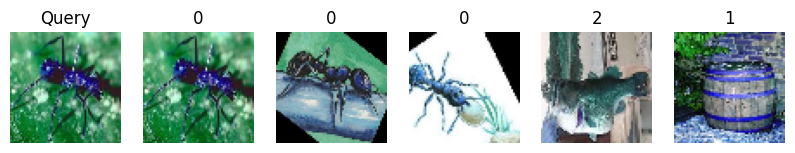

In [24]:
import matplotlib.pyplot as plt

query_index = 10
query_img = images[query_index]

indices = retrieve_similar_images_dl(query_img, top_k=5)

plt.figure(figsize=(10,3))

# Query
plt.subplot(1,6,1)
plt.imshow(query_img)
plt.title("Query")
plt.axis('off')

# Retrieved images
for i, idx in enumerate(indices):
    plt.subplot(1,6,i+2)
    plt.imshow(images[idx])
    plt.title(labels[idx])
    plt.axis('off')

plt.show()

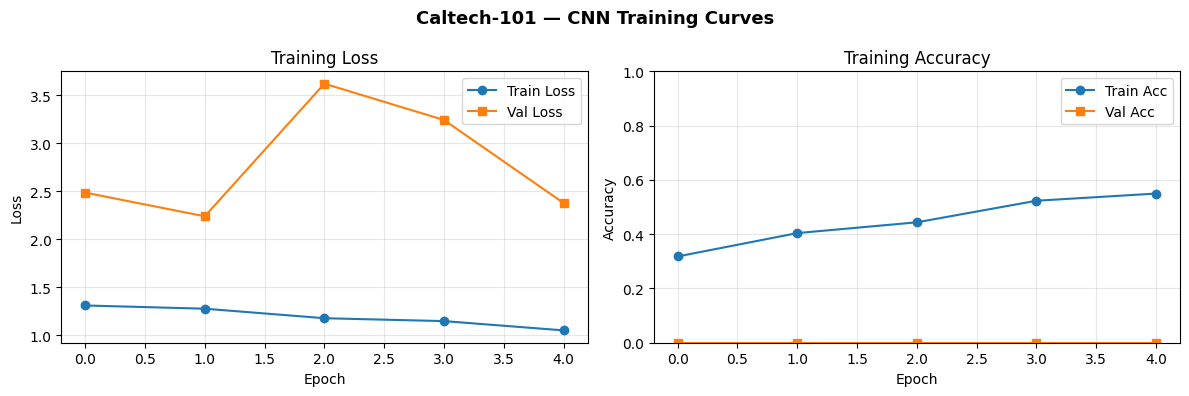

✅ Saved: caltech_cnn_training_curves.png → use in report


In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Caltech-101 — CNN Training Curves',
             fontsize=13, fontweight='bold')

# Loss
axes[0].plot(history.history['loss'], marker='o', label='Train Loss')
axes[0].plot(history.history['val_loss'], marker='s', label='Val Loss')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], marker='o', label='Train Acc')
axes[1].plot(history.history['val_accuracy'], marker='s', label='Val Acc')
axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('caltech_cnn_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

print('✅ Saved: caltech_cnn_training_curves.png → use in report')

In [27]:
print('Extracting Caltech-101 CNN embeddings...')

features = embedding_model.predict(images)
labels_np = np.array(labels)
imgs_np = np.array(images)

print(f'✅ Embeddings shape: {features.shape}')

Extracting Caltech-101 CNN embeddings...
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step
✅ Embeddings shape: (189, 128)


In [28]:
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np

def retrieve(query_feat, features, top_k=5):

    dists = euclidean_distances([query_feat], features)[0]
    indices = np.argsort(dists)[1:top_k+1]  # skip self

    return indices, dists[indices]

In [29]:
def show_retrieval(query_img, query_label, ret_imgs, ret_labels, title):

    plt.figure(figsize=(10,3))

    # Query
    plt.subplot(1,6,1)
    plt.imshow(query_img)
    plt.title(f"Q:{query_label}")
    plt.axis('off')

    # Results
    for i in range(len(ret_imgs)):
        plt.subplot(1,6,i+2)
        plt.imshow(ret_imgs[i])
        plt.title(ret_labels[i])
        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

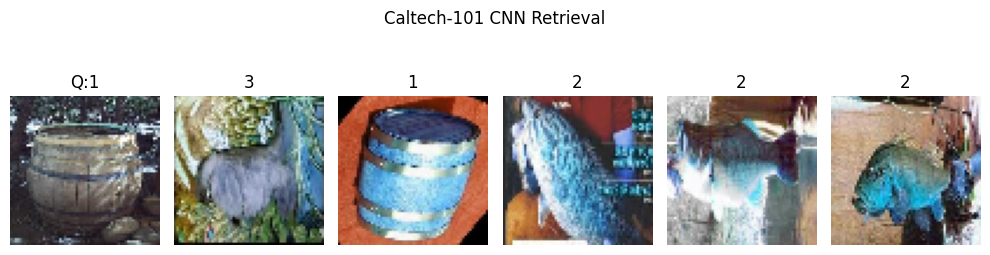

In [30]:
# Pick random query
query_index = np.random.randint(0, len(features))

query_feat = features[query_index]
query_img = imgs_np[query_index]
query_label = labels_np[query_index]

indices, dists = retrieve(query_feat, features)

retrieved_imgs = imgs_np[indices]
retrieved_labels = labels_np[indices]

show_retrieval(
    query_img,
    query_label,
    retrieved_imgs,
    retrieved_labels,
    title="Caltech-101 CNN Retrieval"
)

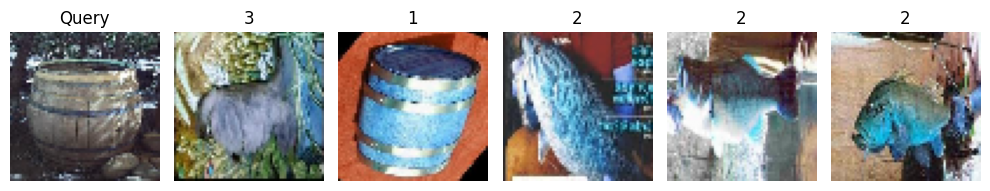

✅ Saved: caltech_cnn_retrieval.png → use in report


In [31]:
plt.figure(figsize=(10,3))

plt.subplot(1,6,1)
plt.imshow(query_img)
plt.title("Query")
plt.axis('off')

for i, idx in enumerate(indices):
    plt.subplot(1,6,i+2)
    plt.imshow(imgs_np[idx])
    plt.title(labels_np[idx])
    plt.axis('off')

plt.tight_layout()
plt.savefig('caltech_cnn_retrieval.png', dpi=120)
plt.show()

print('✅ Saved: caltech_cnn_retrieval.png → use in report')

In [33]:
from skimage.feature import local_binary_pattern
import numpy as np

def extract_lbp_features(image):
    radius = 1
    n_points = 8 * radius

    # Convert to grayscale if needed
    if len(image.shape) == 3:
        image = np.dot(image[...,:3], [0.2989, 0.5870, 0.1140])

    lbp = local_binary_pattern(image, n_points, radius, method='uniform')

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2)
    )

    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)

    return hist

In [34]:
print("Extracting LBP features...")

lbp_features = []

for img in images:
    lbp_features.append(extract_lbp_features(img))

lbp_features = np.array(lbp_features)

print("✅ LBP feature shape:", lbp_features.shape)

Extracting LBP features...
✅ LBP feature shape: (189, 10)


In [35]:
print('📊 Evaluating Caltech-101 — LBP...')
caltech_lbp_metrics = evaluate(lbp_features, labels)

print('📊 Evaluating Caltech-101 — CNN...')
caltech_cnn_metrics = evaluate(features, labels)

📊 Evaluating Caltech-101 — LBP...
📊 Evaluating Caltech-101 — CNN...


In [36]:
print('\n' + '━'*40)
print('  CALTECH-101 RESULTS')
print('━'*40)

print(f'{"Metric":<15} {"LBP":>12} {"CNN":>12}')
print('─'*40)

for metric in caltech_lbp_metrics:
    print(f'  {metric:<13} '
          f'{caltech_lbp_metrics[metric]:>12.4f} '
          f'{caltech_cnn_metrics[metric]:>12.4f}')

print('━'*40)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CALTECH-101 RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Metric                   LBP          CNN
────────────────────────────────────────
  Precision@5         0.2880       0.4900
  Recall@5            0.0303       0.0528
  mAP                 0.4285       0.6358
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


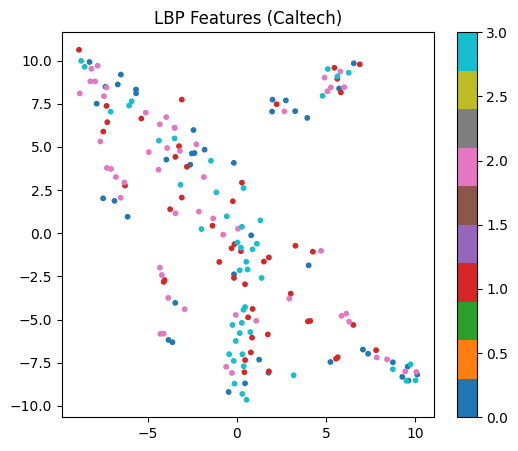

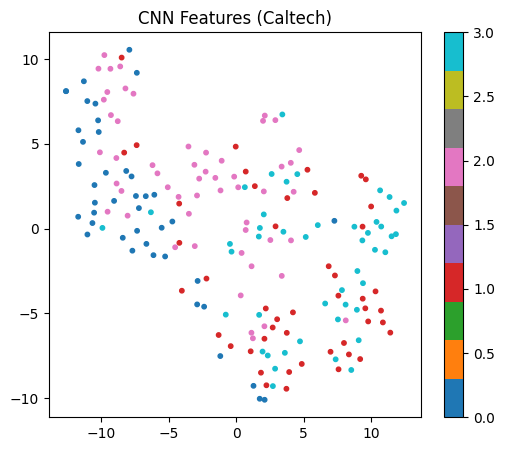

In [37]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_tsne_simple(feats, labels, title):

    tsne = TSNE(n_components=2, random_state=42)
    reduced = tsne.fit_transform(feats)

    plt.figure(figsize=(6,5))
    scatter = plt.scatter(reduced[:,0], reduced[:,1],
                          c=labels, cmap='tab10', s=10)

    plt.title(title)
    plt.colorbar(scatter)
    plt.show()

# Plot both
plot_tsne_simple(lbp_features, labels, "LBP Features (Caltech)")
plot_tsne_simple(features, labels, "CNN Features (Caltech)")

In [38]:
if 'ALL_RESULTS' not in globals():
    ALL_RESULTS = {}

TOP_K = 5

ALL_RESULTS['Caltech-101'] = {
    'LBP': {
        'Precision@5': caltech_lbp_metrics[f'Precision@{TOP_K}'],
        'Recall@5': caltech_lbp_metrics[f'Recall@{TOP_K}'],
        'mAP': caltech_lbp_metrics['mAP'],
        'Remarks': 'Poor — only texture-based'
    },
    'CNN': {
        'Precision@5': caltech_cnn_metrics[f'Precision@{TOP_K}'],
        'Recall@5': caltech_cnn_metrics[f'Recall@{TOP_K}'],
        'mAP': caltech_cnn_metrics['mAP'],
        'Remarks': 'Strong — captures semantics'
    }
}

In [39]:
print('\n' + '═'*75)
print(' FINAL COMPARISON TABLE')
print('═'*75)

print(f'{"Dataset":<12} {"Method":<8} {"Precision@5":>12} '
      f'{"Recall@5":>10} {"mAP":>8}')

print('─'*75)

for ds in ALL_RESULTS:
    for method in ALL_RESULTS[ds]:
        m = ALL_RESULTS[ds][method]

        print(f'  {ds:<10} {method:<8} '
              f'{m["Precision@5"]:>12.4f} '
              f'{m["Recall@5"]:>10.4f} '
              f'{m["mAP"]:>8.4f}')
    print('─'*75)

print('═'*75)


═══════════════════════════════════════════════════════════════════════════
 FINAL COMPARISON TABLE
═══════════════════════════════════════════════════════════════════════════
Dataset      Method    Precision@5   Recall@5      mAP
───────────────────────────────────────────────────────────────────────────
  Caltech-101 LBP            0.2880     0.0303   0.4285
  Caltech-101 CNN            0.4900     0.0528   0.6358
───────────────────────────────────────────────────────────────────────────
═══════════════════════════════════════════════════════════════════════════


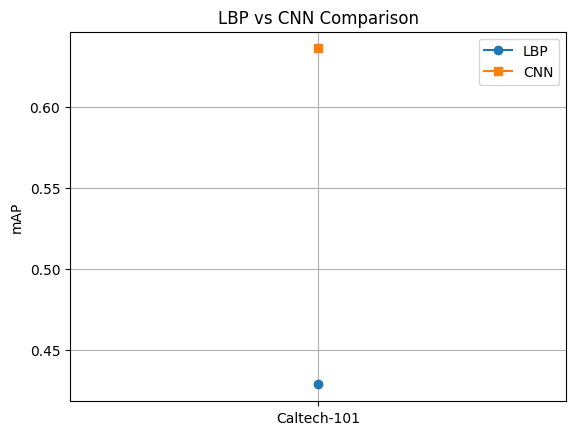

In [40]:
import matplotlib.pyplot as plt

datasets = list(ALL_RESULTS.keys())

lbp_map = [ALL_RESULTS[d]['LBP']['mAP'] for d in datasets]
cnn_map = [ALL_RESULTS[d]['CNN']['mAP'] for d in datasets]

x = range(len(datasets))

plt.plot(x, lbp_map, marker='o', label='LBP')
plt.plot(x, cnn_map, marker='s', label='CNN')

plt.xticks(x, datasets)
plt.ylabel("mAP")
plt.title("LBP vs CNN Comparison")
plt.legend()
plt.grid()

plt.show()